In [1]:
from resources.imports import *
from pathlib import Path

from resources.MLdata import DATA, load_data, UTprops, FTprops, MULTIprops, remove_outliers, save_MLdata, save_MULTIdata, \
                             plot_sampling, get_stats, plot_frequency, plot_properties, plot_curve, save_field_MLdata, save_MULTIfieldData

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
### Global Inputs

save_field_outputs = True

mode = None#("compare", "Target-xs")

DAT = DATA(path=r"Z:/p1/data/Ti/disNodes/0.2/FCC/sims2", 
        path_add="",
        load=False,
        load_split=False,
        split_frac=0.8,
        save_split=False,
        LAT="FCC",
        dis="disNodes", 
        dN=0.2,
        mechMode="MULTI",
        freq=False)

if mode is not None:
    if mode[0].lower() == "compare":
        DATc = DATA(path=1, 
                    path_add=mode[1],
                    load=DAT.load,
                    LAT=DAT.LAT, 
                    dis=DAT.dis, 
                    dN=DAT.dN,
                    mechMode=DAT.mechMode,
                    freq=DAT.freq)

if DAT.LAT.lower() == "fcc":
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "kagome":
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "hex":
    manual_outliersUT = None
    manual_outliersFT = [566]
elif DAT.LAT.lower() == "tri":
    manual_outliersUT = None
    manual_outliersFT = None

# Load Data

In [4]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_INcsv  = DAT.PATH + f'Ductile-{DAT.dis}-IN.csv'
        DAT.UT_OUTcsv = DAT.PATH + f'Ductile-{DAT.dis}-OUT.csv'
        DAT.UT_INcsv_f = None
        if DAT.freq:
            DAT.UT_INcsv_f = DAT.PATH + f'Ductile-{DAT.dis}-INf.csv'

    if DAT.FTmechTest:
        DAT.FT_INcsv  = DAT.PATH + f'Fracture-{DAT.dis}-IN.csv'
        DAT.FT_OUTcsv = DAT.PATH + f'Fracture-{DAT.dis}-OUT.csv'
        DAT.FT_INcsv_f = None
        if DAT.freq:
            DAT.FT_INcsv_f = DAT.PATH + f'Fracture-{DAT.dis}-INf.csv'

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_INcsv  = DATc.PATH + f'Ductile-{DATc.dis}-IN.csv'
            DATc.UT_OUTcsv = DATc.PATH + f'Ductile-{DATc.dis}-OUT.csv'
            DATc.UT_INcsv_f = None
            if DATc.freq:
                DATc.UT_INcsv_f = DATc.PATH + f'Ductile-{DATc.dis}-INf.csv'

        if DATc.FTmechTest:
            DATc.FT_INcsv  = DATc.PATH + f'Fracture-{DATc.dis}-IN.csv'
            DATc.FT_OUTcsv = DATc.PATH + f'Fracture-{DATc.dis}-OUT.csv'
            DATc.FT_INcsv_f = None
            if DATc.freq:
                DATc.FT_INcsv_f = DATc.PATH + f'Fracture-{DATc.dis}-INf.csv'

In [5]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_INf_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_dINr_df, DAT.UT_dOUTr_df, DAT.UT_props_df = load_data(DAT.UT_INcsv, DAT.UT_OUTcsv, DAT.UT_INcsv_f)

    if DAT.FTmechTest:
        DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_INf_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_dINr_df, DAT.FT_dOUTr_df, DAT.FT_props_df = load_data(DAT.FT_INcsv, DAT.FT_OUTcsv, DAT.FT_INcsv_f)

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_INf_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_dINr_df, DATc.UT_dOUTr_df, DATc.UT_props_df = load_data(DATc.UT_INcsv, DATc.UT_OUTcsv, DATc.UT_INcsv_f)

        if DATc.FTmechTest:
            DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_INf_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_dINr_df, DATc.FT_dOUTr_df, DATc.FT_props_df = load_data(DATc.FT_INcsv, DATc.FT_OUTcsv, DATc.FT_INcsv_f)

# Geometry

In [6]:
if DAT.load is not True:
    DAT.geom.FTcalc()

# Prep Data

In [7]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_props_r_df = UTprops(DAT.UT_OUT_df)
        DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_df, DAT.UT_INf_df = remove_outliers(DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_props_r_df, DAT.UT_INf_df, manual=manual_outliersUT)
        save_MLdata(DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_props_df, DAT.PATH, "UT", DAT.dis, DAT.UT_INf_df)

    if DAT.FTmechTest:
        DAT.FT_props_r_df = FTprops(DAT.FT_OUT_df, DAT.geom, DAT.E_eff_pe)
        DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_props_df, DAT.FT_INf_df = remove_outliers(DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_props_r_df, DAT.FT_INf_df, manual=manual_outliersFT)
        save_MLdata(DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_props_df, DAT.PATH, "FT", DAT.dis, DAT.FT_INf_df)

    if DAT.UTmechTest and DAT.FTmechTest:
        DAT.common_props_df, DAT.common_IN_dfs, DAT.common_OUT_dfs, DAT.common_dIN_dfs, DAT.common_dOUT_dfs, DAT.common_INf_dfs = MULTIprops([DAT.UT_IN_df, DAT.FT_IN_df], [DAT.UT_OUT_df, DAT.FT_OUT_df], [DAT.UT_dIN_df, DAT.FT_dIN_df] , [DAT.UT_dOUT_df, DAT.FT_dOUT_df], [DAT.UT_props_df, DAT.FT_props_df], [DAT.UT_INf_df, DAT.FT_INf_df], DAT.E_eff_pe)
        save_MULTIdata(DAT.common_IN_dfs, DAT.common_OUT_dfs, DAT.common_props_df, DAT.PATH, DAT.dis, DAT.common_INf_dfs)

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_props_r_df = UTprops(DATc.UT_OUT_df)
            DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_props_df, DATc.UT_INf_df = remove_outliers(DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_props_r_df, DATc.UT_INf_df, manual=manual_outliersUT)
            save_MLdata(DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_props_df, DATc.PATH, "UT", DATc.dis, DATc.UT_INf_df)
        
        if DATc.FTmechTest:
            DATc.FT_props_r_df = FTprops(DATc.FT_OUT_df, DATc.geom, DATc.E_eff_pe)
            DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_props_df, DATc.FT_INf_df = remove_outliers(DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_props_r_df, DATc.FT_INf_df, manual=manual_outliersFT)
            save_MLdata(DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_props_df, DATc.PATH, "FT", DATc.dis, DATc.FT_INf_df)

        if DATc.UTmechTest and DATc.FTmechTest:
            DATc.common_props_df, DATc.common_IN_dfs, DATc.common_OUT_dfs, DATc.common_dIN_dfs, DATc.common_dOUT_dfs, DATc.common_INf_dfs = MULTIprops([DATc.UT_IN_df, DATc.FT_IN_df], [DATc.UT_OUT_df, DATc.FT_OUT_df], [DATc.UT_dIN_df, DATc.FT_dIN_df] , [DATc.UT_dOUT_df, DATc.FT_dOUT_df], [DATc.UT_props_df, DATc.FT_props_df], [DATc.UT_INf_df, DATc.FT_INf_df], DATc.E_eff_pe)
            save_MULTIdata(DATc.common_IN_dfs, DATc.common_OUT_dfs, DATc.common_props_df, DATc.PATH, DATc.dis, DATc.common_INf_dfs)

# Field Outputs


In [8]:
if save_field_outputs and DAT.load is not True:
    missing_field_outputs = []
    DAT.UT_FIELDnpz = Path(DAT.PATH) / f"Ductile-{DAT.dis}-FIELDu.npz"
    DAT.FT_FIELDnpz = Path(DAT.PATH) / f"Fracture-{DAT.dis}-FIELDu.npz"

    if DAT.UTmechTest:
        if DAT.UT_FIELDnpz.exists():
            DAT.UT_ML_FIELDnpz = save_field_MLdata(DAT.UT_FIELDnpz, DAT.UT_IN_df, DAT.PATH, "UT", DAT.dis, mechMode="UT")
        else:
            missing_field_outputs.append(DAT.UT_FIELDnpz)

    if DAT.FTmechTest:
        if DAT.FT_FIELDnpz.exists():
            DAT.FT_ML_FIELDnpz = save_field_MLdata(DAT.FT_FIELDnpz, DAT.FT_IN_df, DAT.PATH, "FT", DAT.dis, mechMode="FT")
        else:
            missing_field_outputs.append(DAT.FT_FIELDnpz)

    if DAT.UTmechTest and DAT.FTmechTest and DAT.UT_FIELDnpz.exists() and DAT.FT_FIELDnpz.exists():
        DAT.common_ML_FIELDnpzs = save_MULTIfieldData(DAT.UT_FIELDnpz, DAT.FT_FIELDnpz, DAT.common_props_df, DAT.PATH, DAT.dis)

    if mode is not None and mode[0].lower() == "compare":
        DATc.UT_FIELDnpz = Path(DATc.PATH) / f"Ductile-{DATc.dis}-FIELDu.npz"
        DATc.FT_FIELDnpz = Path(DATc.PATH) / f"Fracture-{DATc.dis}-FIELDu.npz"

        if DATc.UTmechTest:
            if DATc.UT_FIELDnpz.exists():
                DATc.UT_ML_FIELDnpz = save_field_MLdata(DATc.UT_FIELDnpz, DATc.UT_IN_df, DATc.PATH, "UT", DATc.dis, mechMode="UT")
            else:
                missing_field_outputs.append(DATc.UT_FIELDnpz)

        if DATc.FTmechTest:
            if DATc.FT_FIELDnpz.exists():
                DATc.FT_ML_FIELDnpz = save_field_MLdata(DATc.FT_FIELDnpz, DATc.FT_IN_df, DATc.PATH, "FT", DATc.dis, mechMode="FT")
            else:
                missing_field_outputs.append(DATc.FT_FIELDnpz)

        if DATc.UTmechTest and DATc.FTmechTest and DATc.UT_FIELDnpz.exists() and DATc.FT_FIELDnpz.exists():
            DATc.common_ML_FIELDnpzs = save_MULTIfieldData(DATc.UT_FIELDnpz, DATc.FT_FIELDnpz, DATc.common_props_df, DATc.PATH, DATc.dis)

    if missing_field_outputs:
        print("WARNING: Missing field output .npz files; skipped ML field export for:")
        for field_npz in missing_field_outputs:
            print(f"  - {field_npz}")


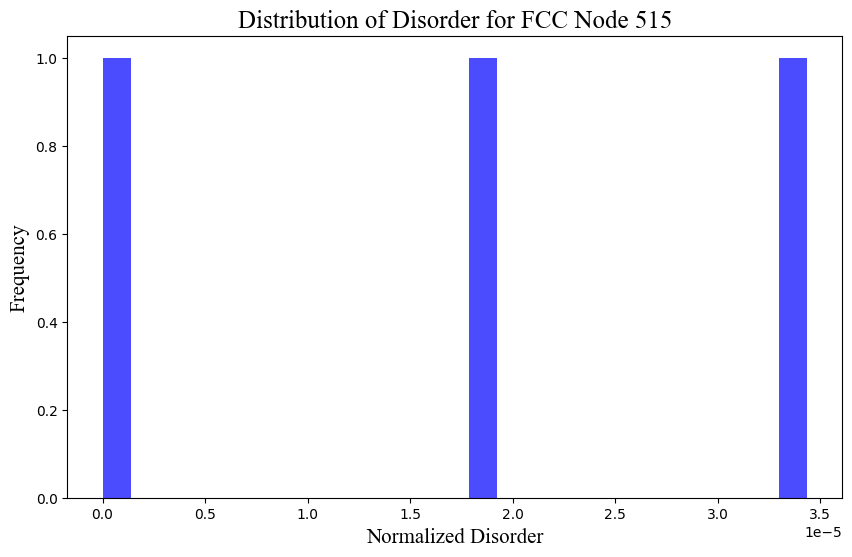

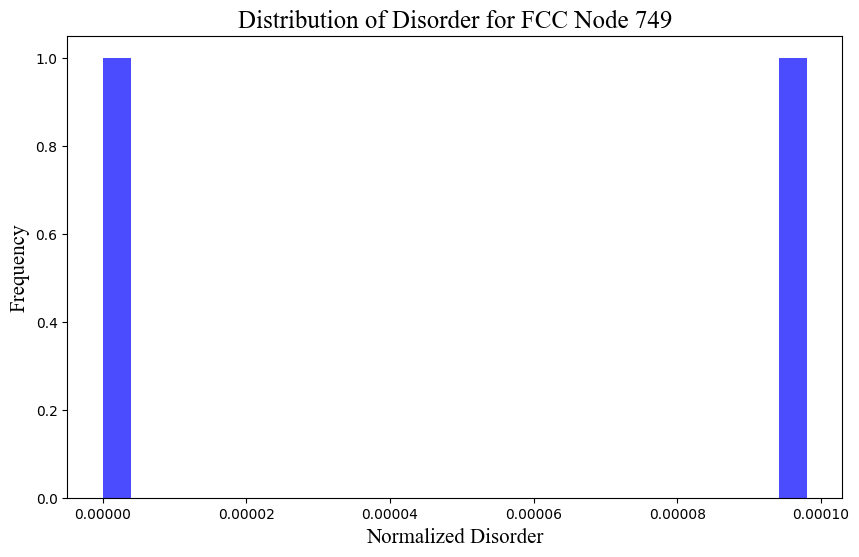

In [9]:
if DAT.UTmechTest:
    plot_sampling(DAT.UT_dIN_df, DAT.LAT, DAT.geom.l, indx=None, num=1, by="Node")
if DAT.FTmechTest:
    plot_sampling(DAT.FT_dIN_df, DAT.LAT, DAT.geom.l, indx=None, num=1, by="Node")

In [10]:
if DAT.UTmechTest:
    DAT.UT_stats, DAT.UT_nSims = get_stats(DAT.UT_props_df)
    print("FINAL UT SIMULATION COUNT:", len(DAT.UT_OUT_df)-1)
    print(f"{pd.concat([DAT.UT_stats, DAT.UT_nSims])}\n\n")

if DAT.FTmechTest:
    DAT.FT_stats, DAT.FT_nSims = get_stats(DAT.FT_props_df)
    print("FINAL FT SIMULATION COUNT:", len(DAT.FT_OUT_df)-1)
    print(f"{pd.concat([DAT.FT_stats, DAT.FT_nSims])}\n\n")

if DAT.UTmechTest and DAT.FTmechTest:
    DAT.common_stats, DAT.common_nSims = get_stats(DAT.common_props_df)
    print("FINAL COMMON SIMULATION COUNT:", len(DAT.common_props_df)-1)
    print(f"{pd.concat([DAT.common_stats, DAT.common_nSims])}\n\n")

if mode is not None and mode[0].lower() == "compare":
    print("\n=============== COMPARISON DATA ===============\n")
    if DATc.UTmechTest:
        DATc.UT_stats, DATc.UT_nSims = get_stats(DATc.UT_props_df)
        print("FINAL UT SIMULATION COUNT:", len(DATc.UT_OUT_df)-1)
        print(f"{pd.concat([DATc.UT_stats, DATc.UT_nSims])}\n\n")

    if DATc.FTmechTest:
        DATc.FT_stats, DATc.FT_nSims = get_stats(DATc.FT_props_df)
        print("FINAL FT SIMULATION COUNT:", len(DATc.FT_OUT_df)-1)
        print(f"{pd.concat([DATc.FT_stats, DATc.FT_nSims])}\n\n")

    if DATc.UTmechTest and DATc.FTmechTest:
        DATc.common_stats, DATc.common_nSims = get_stats(DATc.common_props_df)
        print("FINAL COMMON SIMULATION COUNT:", len(DATc.common_props_df)-1)
        print(f"{pd.concat([DATc.common_stats, DATc.common_nSims])}\n\n")

FINAL UT SIMULATION COUNT: 3
           Ductility    Strength    Stiffness         WoF
Mean        0.042542   60.493528  7224.510879    1.768697
Std         0.004655    0.281933     0.832868    0.100953
\%d Mean    0.689198   -0.047491    -0.021791    0.230897
\%d Std    -0.815160   -0.995561    -0.999887   -0.929743
Max       397.000000  397.000000   747.000000  397.000000
Min       747.000000  747.000000   397.000000  747.000000


FINAL FT SIMULATION COUNT: 2
                 K_JIC          K_IC         Force  Displacement
Mean      4.162659e+07  2.711203e+07  90118.812812      0.008968
Std                NaN           NaN           NaN           NaN
\%d Mean  2.223721e-01 -2.581278e-03     -0.002581      0.456756
\%d Std            NaN           NaN           NaN           NaN
Max       7.470000e+02  7.470000e+02    747.000000    747.000000
Min       7.470000e+02  7.470000e+02    747.000000    747.000000


FINAL COMMON SIMULATION COUNT: 1
           Ductility    Strength    Stiffnes

In [11]:
if DAT.UTmechTest:
    print(f"{(DAT.UT_props_df.loc[DAT.UT_nSims['Ductility'].loc['Max']]-DAT.UT_props_df.iloc[0])/DAT.UT_props_df.iloc[0]}\n\n")

if DAT.FTmechTest:
    print(f"{(DAT.FT_props_df.loc[DAT.FT_nSims['K_JIC'].loc['Max']]-DAT.FT_props_df.iloc[0])/DAT.FT_props_df.iloc[0]}\n\n")

if DAT.UTmechTest and DAT.FTmechTest:
    print(f"{(DAT.common_props_df.loc[DAT.common_nSims['FCL'].loc['Max']]-DAT.common_props_df.iloc[0])/DAT.common_props_df.iloc[0]}\n\n")
    print(f"{(DAT.common_props_df.loc[DAT.common_nSims['Multi'].loc['Max']]-DAT.common_props_df.iloc[0])/DAT.common_props_df.iloc[0]}\n\n")

if mode is not None and mode[0].lower() == "compare":
    print("\n=============== COMPARISON DATA ===============\n")
    if DATc.UTmechTest:
        print(f"{(DATc.UT_props_df.loc[DATc.UT_nSims['Ductility'].loc['Max']]-DATc.UT_props_df.iloc[0])/DATc.UT_props_df.iloc[0]}\n\n")

    if DATc.FTmechTest:
        print(f"{(DATc.FT_props_df.loc[DATc.FT_nSims['K_JIC'].loc['Max']]-DATc.FT_props_df.iloc[0])/DATc.FT_props_df.iloc[0]}\n\n")

    if DATc.UTmechTest and DATc.FTmechTest:
        print(f"{(DATc.common_props_df.loc[DATc.common_nSims['FCL'].loc['Max']]-DATc.common_props_df.iloc[0])/DATc.common_props_df.iloc[0]}\n\n")
        print(f"{(DATc.common_props_df.loc[DATc.common_nSims['Multi'].loc['Max']]-DATc.common_props_df.iloc[0])/DATc.common_props_df.iloc[0]}\n\n")

Ductility    0.819900
Strength    -0.044352
Stiffness   -0.021871
WoF          0.280576
dtype: float64


K_JIC           0.222372
K_IC           -0.002581
Force          -0.002581
Displacement    0.456756
dtype: float64


Ductility       0.558496
Strength       -0.050630
Stiffness      -0.021712
WoF             0.181218
K_JIC           0.222372
K_IC           -0.002581
Force          -0.002581
Displacement    0.456756
Multi           0.502089
FCL             0.264960
dtype: float64


Ductility       0.558496
Strength       -0.050630
Stiffness      -0.021712
WoF             0.181218
K_JIC           0.222372
K_IC           -0.002581
Force          -0.002581
Displacement    0.456756
Multi           0.502089
FCL             0.264960
dtype: float64




# Plot Distribution & Identify Max, Min Simulations

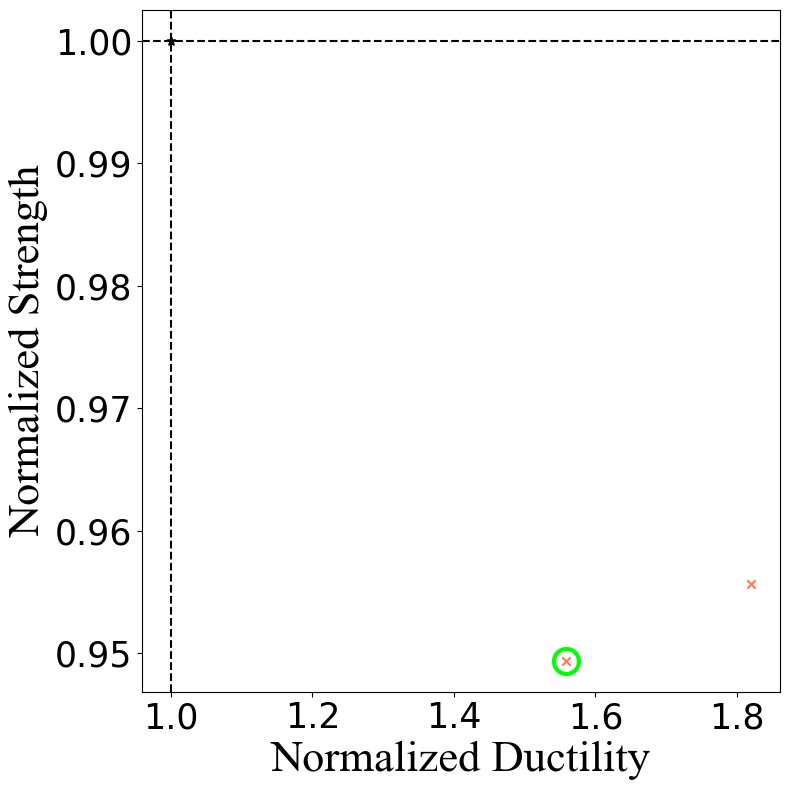

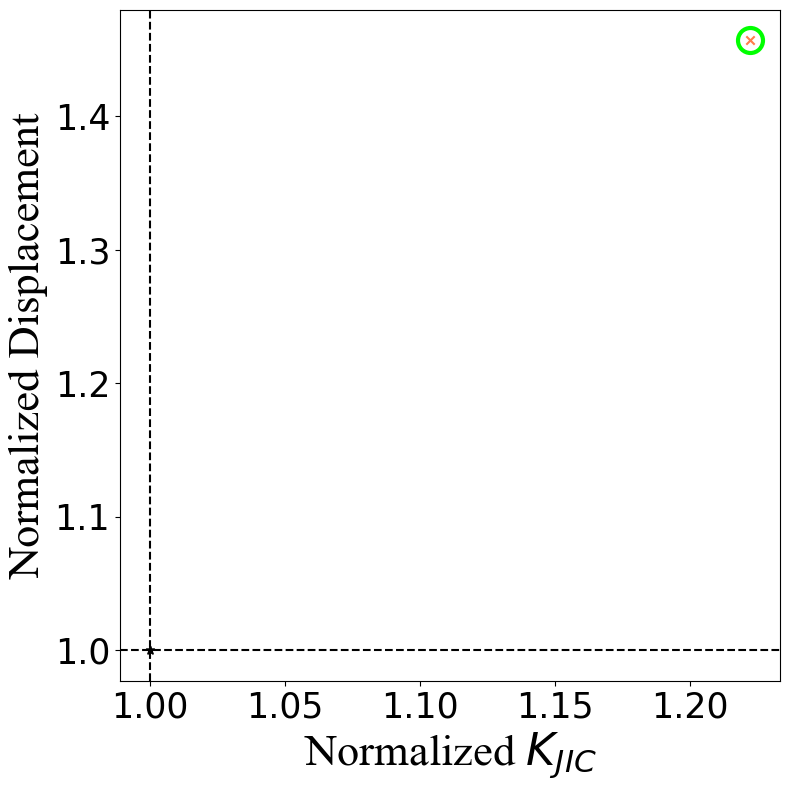

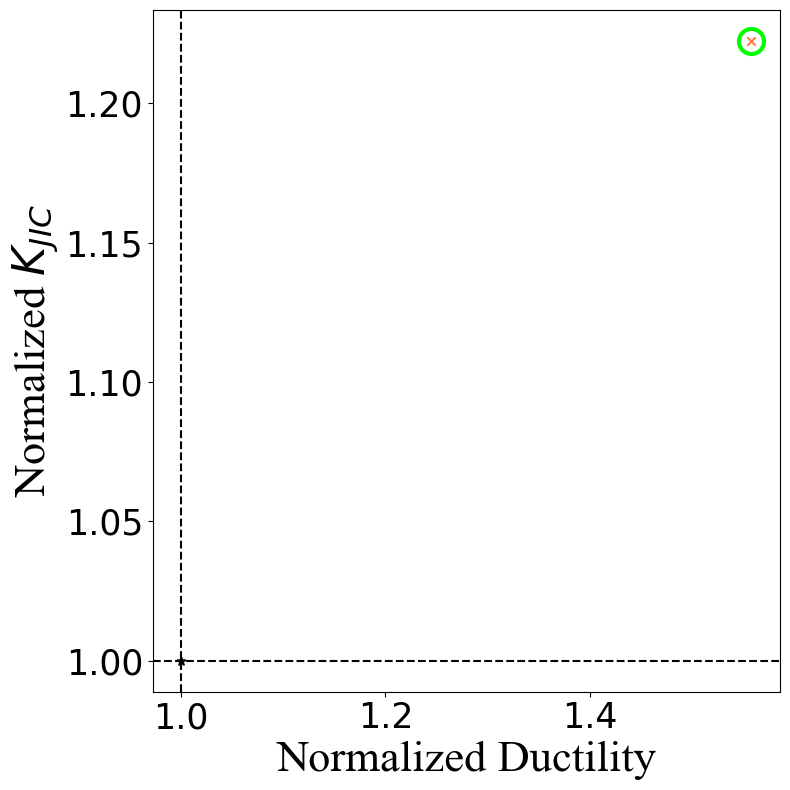

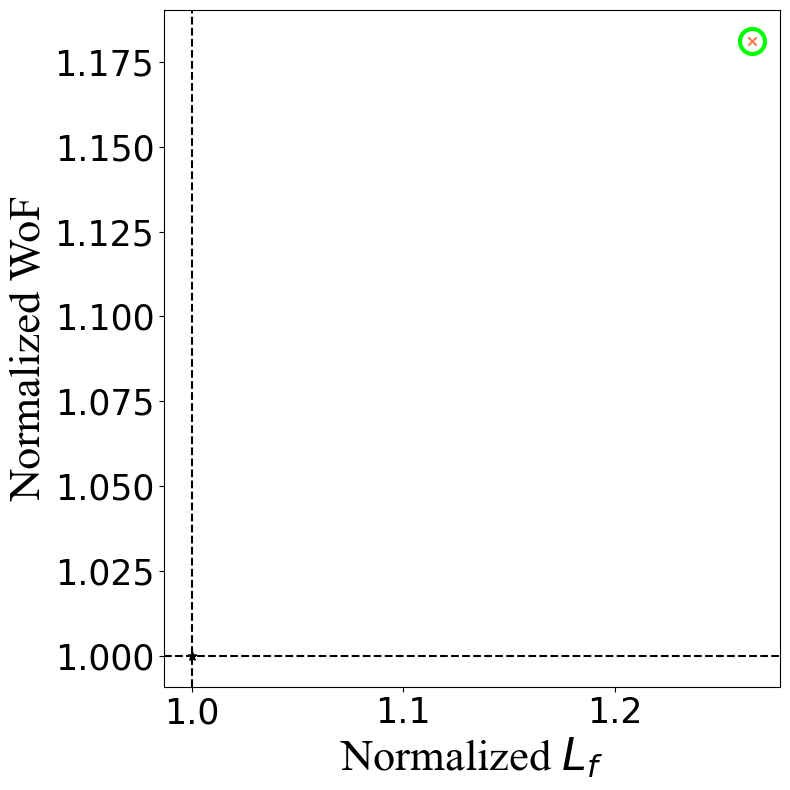

In [12]:
plot_allProps = True
plot_freq = False
plot_ONLY_freq = False

if plot_allProps:
    if DAT.UTmechTest:  
        fig, ax = plot_properties(DAT.UT_props_df["Ductility"], DAT.UT_props_df["Strength"], "UT", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.UT_props_df["Ductility"], DATc.UT_props_df["Strength"], "UT", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
    
    if DAT.FTmechTest:  
        fig, ax = plot_properties(DAT.FT_props_df["K_JIC"], DAT.FT_props_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.FT_props_df["K_JIC"], DATc.FT_props_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
   
    if DAT.UTmechTest and DAT.FTmechTest:   
        fig, ax = plot_properties(DAT.common_props_df["Ductility"], DAT.common_props_df["K_JIC"], "MULTI", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.common_props_df["Ductility"], DATc.common_props_df["K_JIC"], "MULTI", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
            
        fig, ax = plot_properties(DAT.common_props_df["FCL"], DAT.common_props_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.common_props_df["FCL"], DATc.common_props_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.mechMode.lower() == "multi" else None)

if plot_ONLY_freq and DAT.load is not True:
    if DAT.UTmechTest:
        plot_frequency(DAT.UT_props_r_df["Ductility"], DAT.UT_props_df["Ductility"], "UT", bins=30)
    if DAT.FTmechTest:
        plot_frequency(DAT.FT_props_r_df["K_JIC"], DAT.FT_props_df["K_JIC"], "FT", bins=30)
    if DAT.UTmechTest and DAT.FTmechTest:
        plot_frequency(DAT.common_props_df["FCL"], DAT.common_props_df["FCL"], "FCL", bins=30)

# Plots UT and FT Curves

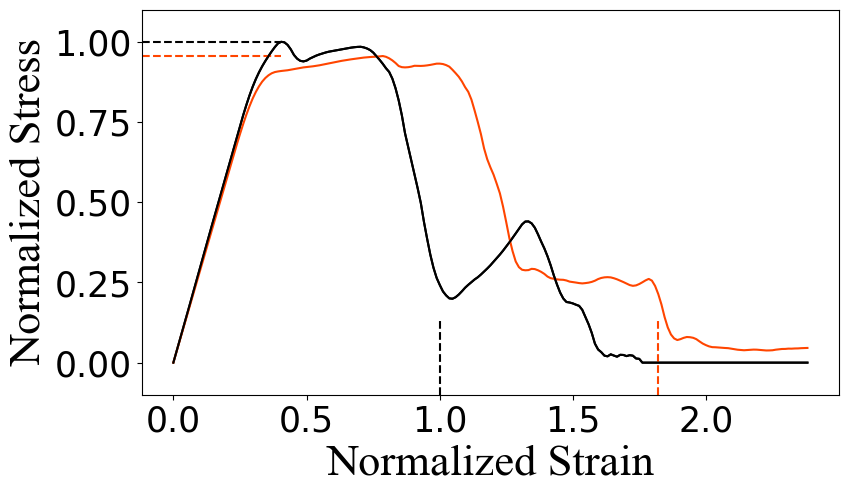

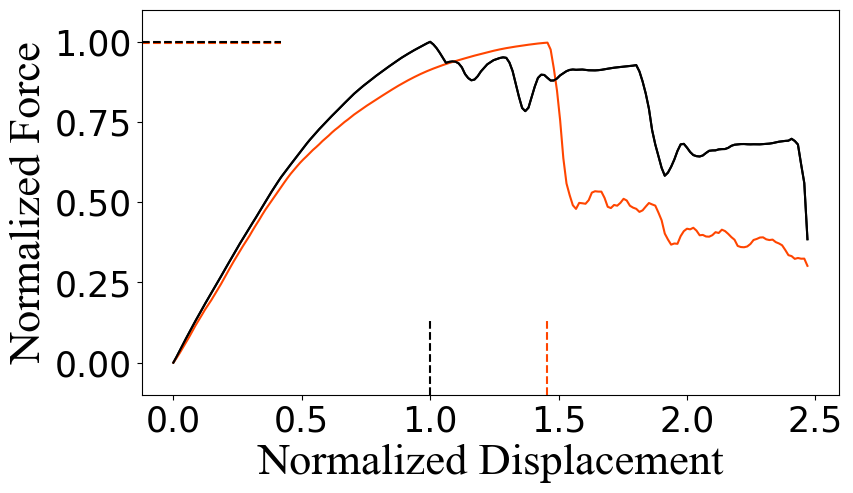

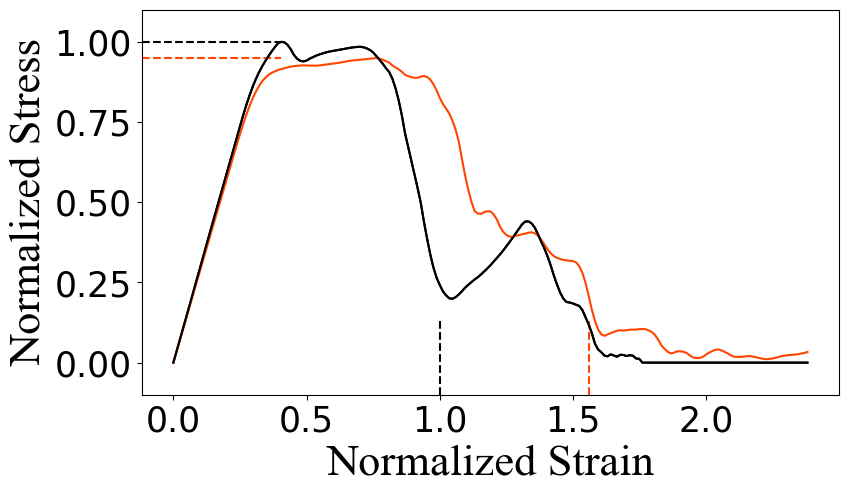

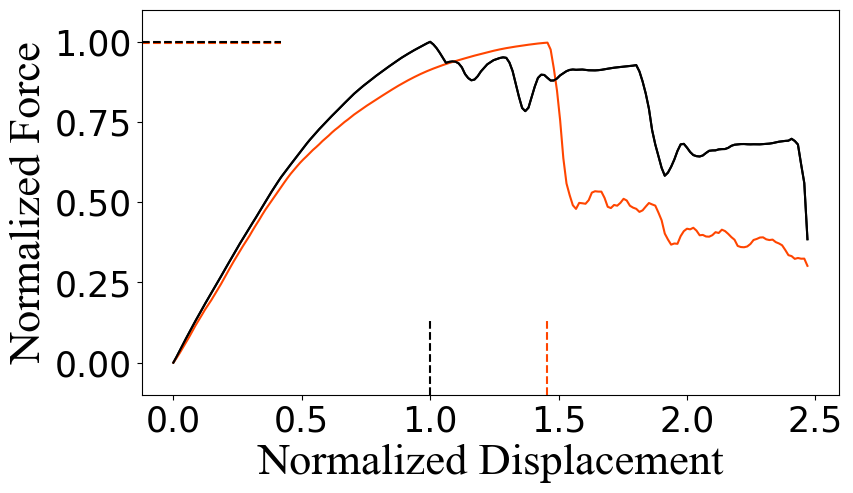

In [13]:
idx = None
q   = "all"
if DAT.UTmechTest:
    fig2, ax1 = plot_curve(DAT.UT_OUT_df, "ut", idx=[DAT.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.UT_OUT_df, "ut", idx=[DATc.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
    
if DAT.FTmechTest:
    fig2, ax1 = plot_curve(DAT.FT_OUT_df, "ft", idx=[DAT.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.FT_OUT_df, "ft", idx=[DATc.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
    
if DAT.UTmechTest and DAT.FTmechTest:
    fig2, ax1 = plot_curve(DAT.UT_OUT_df, "ut", idx=[DAT.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.UT_OUT_df, "ut", idx=[DATc.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
        
    fig2, ax1 = plot_curve(DAT.FT_OUT_df, "ft", idx=[DAT.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.FT_OUT_df, "ft", idx=[DATc.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=(fig2, ax1))